# 04 · The evolutionary optimizer

The search keeps a population of candidate equations and improves it for a given
number of epochs:

1. **Variation.** Crossover exchanges terms between equations; mutation replaces
   terms or factors with new ones from the token pool.
2. **Coefficients and sparsity.** For each candidate, one term is taken as the
   left-hand side, the coefficients of the others are fitted, and a sparsity
   operator removes terms that do not carry weight.
3. **Scoring.** Every candidate gets two objective values: the discrepancy
   between its sides and either the instability of its coefficients across
   parts of the data or its complexity.
4. **Selection.** The multiobjective algorithm (decomposition into subproblems
   with neighbourhoods) keeps the non-dominated candidates; the final first
   level is the Pareto front.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

EPDE imported; notebook environment ready


## Settings of the evolution and of the objectives

In [2]:
from dataclasses import asdict
from epde.interface.search_config import load_search_config, METRIC_MENUS, SPARSITY_REGISTRY
cfg = load_search_config(resolve_for_problem(load_config('vdp'), datasets.load('vdp')))
evolution = asdict(cfg.evolution)
operators = evolution.pop('operators')
print('evolution:', evolution)
print('operators:', list(operators))
print('objectives:', asdict(cfg.objectives))

evolution: {'population_size': 16, 'training_epochs': 5, 'neighbors_number': 3, 'PBI_penalty': 5.0, 'subregion_mating_limitation': 0.9, 'solution_params': {}, 'director_params': {'variation_params': {}, 'mutation_params': {}, 'sorter_params': {}, 'pareto_combiner_params': {}, 'pareto_updater_params': {}}}
operators: ['MOEADDSelection', 'PopulationUpdater', 'SortingBasedNeighborSelector', 'ParetoLevelUpdater', 'InitialParetoLevelSorting', 'SolverFreeFitness', 'SolverBasedFitness', 'DiscrepancyBasedFitnessWithCV', 'PIC', 'DeepXDEBasedFitness', 'ParetoLevelsCrossover', 'ChromosomeCrossover', 'MetaparamerCrossover', 'EquationCrossover', 'TermCrossover', 'TermParamCrossover', 'SystemMutation', 'EquationMutation', 'MetaparameterMutation', 'TermMutation', 'TermParameterMutation', 'LinRegCoeffCalc', 'LASSOBasedSparsity']
objectives: {'multiobjective_mode': True, 'discrepancy_metric': 'wape', 'second_objective': 'instability', 'complexity_metric': 'factors', 'instability_metric': 'chi2', 'singl

Available choices for the objectives and the sparsity operator:

In [3]:
for key, menu in METRIC_MENUS.items():
    print(f'{key:24} {menu}')
print(f"{'sparsity operator':24} {SPARSITY_REGISTRY}")

discrepancy_metric       ('wape', 'l2', 'l2_relative', 'scale_invariant')
complexity_metric        ('factors', 'terms')
instability_metric       ('vcoef', 'cv', 'survival', 'tile', 'het', 'chi2', 'chi2_centered', 'het_raw')
single_objective_metric  ('discrepancy', 'instability')
second_objective         ('instability', 'complexity')
sparsity operator        ('vwsr', 'lasso', 'knee')


## Run the optimizer directly and watch each epoch

This small, live example uses 121 samples of a damped oscillator,
$u(t)=e^{-t/4}\sin t$, and its exact first and second derivatives.
The known law is $u'' + 0.5u' + 1.0625u=0$.
Supplying exact derivatives isolates the evolutionary step from differentiation.

Four candidates evolve for three epochs with the existing discrepancy,
coefficient stability and sparsity settings. We build the token pool, construct
an optimizer, attach the existing sequence of evolutionary operators and run it
directly. At each epoch an observation callback copies the current front;
it never changes candidates, their scores or the stopping rule.
The population and equation sizes are reduced only to keep this demonstration
short. These settings are not the benchmark protocol.

In [4]:
import contextlib, io
from epde_bench import env
from epde_bench.problem import Problem, mesh
from epde_bench.runner import build_search
from epde.optimizers.moeadd.moeadd import MOEADDOptimizer
from epde.operators.common.objectives import ideal_point

env.seed_everything(7)
t = np.linspace(0, 6, 121)
decay = np.exp(-0.25 * t)
demo = Problem('optimizer_demo', 'Damped oscillator', 'ode', 'synthetic',
               mesh(t), {'u': decay * np.sin(t)}, ('t',))
demo.derivs = [np.column_stack((
    decay * (np.cos(t) - 0.25 * np.sin(t)),
    decay * (-0.9375 * np.sin(t) - 0.5 * np.cos(t))))]
demo.deriv_orders = [2]
demo_cfg = load_config('ode', overrides={'search': {
    'preprocessing': {'max_deriv_order': [2]},
    'search_space': {'data_fun_pow': 2, 'deriv_fun_pow': 1,
                     'equation_terms_max_number': 4,
                     'equation_factors_max_number': 1},
    'evolution': {'population_size': 4, 'training_epochs': 3,
                  'neighbors_number': 2}}})
demo_search_cfg = resolve_for_problem(demo_cfg, demo)
with contextlib.redirect_stdout(io.StringIO()):
    demo_search, demo_trajectory, demo_families = build_search(demo, demo_search_cfg)
    demo_search.create_pool(data=[demo_trajectory], additional_tokens=demo_families)

optimizer_params = dict(demo_search.optimizer_init_params)
optimizer_params['population_instruct'] = {
    'pool': demo_search.pool, 'terms_number': 4, 'max_factors_in_term': 1,
    'sparsity_interval': (1., 1.), 'second_objective': 'instability'}
optimizer_params['best_sol_vals'] = ideal_point(('discrepancy', 'instability'))
optimizer = MOEADDOptimizer(**optimizer_params)
optimizer.set_strategy(demo_search.director)
print('Existing strategy blocks:', list(optimizer.sector_processer.linked_blocks.blocks_labeled))

self.vars_demand_equation {'u'}
Existing strategy blocks: ['initial', 'initial_sorter', 'selection', 'variation', 'pareto_updater_compl']


In [5]:
import copy
import pandas as pd
history = []
def observe_front(snapshot, epoch_idx):
    history.append({'epoch': int(epoch_idx) + 1, 'front': copy.deepcopy(snapshot)})
    return False

started = time.perf_counter()
with contextlib.redirect_stdout(io.StringIO()):
    optimizer.optimize(epochs=3, early_stopping_callback=observe_front)
print(f'Live optimizer run: {time.perf_counter() - started:.3f} seconds')
assert [entry['epoch'] for entry in history] == [1, 2, 3]
assert all(entry['front'] for entry in history)
rows = []
for entry in history:
    values = np.asarray([s['obj_fun'] for s in entry['front']], dtype=float)
    assert np.isfinite(values).all()
    rows.append({'Epoch': entry['epoch'], 'Front size': len(values),
                 'Smallest discrepancy': values[:, 0].min(),
                 'Smallest instability': values[:, 1].min()})
display(pd.DataFrame(rows))
print('Final discovered candidates:')
for candidate in history[-1]['front']:
    print(candidate['text_form'])

Live optimizer run: 0.465 seconds


,Epoch,Front size,Smallest discrepancy,Smallest instability
0,1,1,9.606100e-17,1.133215e-31
1,2,1,9.606100e-17,1.133215e-31
2,3,1,9.606100e-17,1.133215e-31


Final discovered candidates:
-1.0625 * u{power: 1.0} + -0.49999999999999994 * du/dx0{power: 1.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'max_terms_number': {'optimizable': False, 'value': 4}, 'max_factors_in_term': {'optimizable': False, 'value': 1}, ('sparsity', 'u'): {'optimizable': True, 'value': np.float64(1.0)}}


The table and plots show observations, rather than a guaranteed improvement.
A front may remain unchanged after the first epoch, especially on exact data.
The two smallest scores in the table can belong to different candidates.
A small score alone does not establish the correct equation: compare the
printed discovered terms with the known oscillator law above.

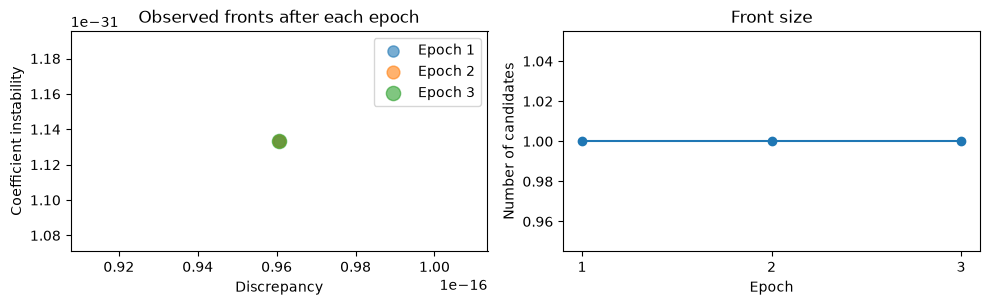

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
for entry in history:
    values = np.asarray([s['obj_fun'] for s in entry['front']], dtype=float)
    axes[0].scatter(values[:, 0], values[:, 1], s=45 + 20 * entry['epoch'],
                    alpha=0.6, label=f"Epoch {entry['epoch']}")
axes[0].set(xlabel='Discrepancy', ylabel='Coefficient instability',
            title='Observed fronts after each epoch')
axes[0].legend()
axes[1].plot([r['Epoch'] for r in rows], [r['Front size'] for r in rows], 'o-')
axes[1].set(xlabel='Epoch', ylabel='Number of candidates', title='Front size')
axes[1].set_xticks([1, 2, 3])
fig.tight_layout()
plt.show()
demo_search.close()

## Optional comparisons on the full record

The following comparisons may reuse a compatible saved run or recompute it
when data, dependencies, code or settings change. They take longer and are
turned off by default. Enable them in the next cell to obtain current results;
no comparison result is claimed while they are skipped.

In [7]:
RUN_EXTENDED_COMPARISONS = False

## Budget: population and epochs

The cost of a run grows with population size times the number of epochs. On the
Van der Pol oscillator:

In [8]:
if RUN_EXTENDED_COMPARISONS:
    for epochs in [2, 5, 10]:
        rec = cached_run('vdp', overrides={'search': {'evolution': {'training_epochs': epochs}}})
        if rec['status'] != 'ok':
            print('search did not complete:', rec['status'], rec.get('error', ''))
            continue
        m = rec['metrics']
        print(f"epochs {epochs:2d}: {rec['fit_seconds']:5.1f} s, front {m['front_size']}, "
              f"truth on front {m['success_front']}, min Hamming {m['hamming_min']}")
else:
    print('Extended comparison skipped; set RUN_EXTENDED_COMPARISONS = True to run it.')

Extended comparison skipped; set RUN_EXTENDED_COMPARISONS = True to run it.


## Different objective settings on the same data

The shipped settings against two variants of the benchmark: the earlier EPDE
setup (squared error, LASSO sparsity, complexity as the second objective) and
sparsity chosen at the knee of the error-versus-size curve.

In [9]:
if RUN_EXTENDED_COMPARISONS:
    for variant in ['default', 'legacy', 'knee']:
        rec = cached_run('vdp', variant=variant)
        m = rec.get('metrics', {})
        print(f"{variant:8} {rec['status']:4} {rec.get('fit_seconds', 0):5.0f} s  front {m.get('front_size')}  "
              f"truth on front {m.get('success_front')}  compromise correct {m.get('success_selected')}")
        for system in rec.get('front', [])[:3]:
            print('          ', system[0])
else:
    print('Extended comparison skipped; set RUN_EXTENDED_COMPARISONS = True to run it.')

Extended comparison skipped; set RUN_EXTENDED_COMPARISONS = True to run it.
